In [ ]:
!pip install kagglehub shap -q

## 0.1 Import Library and Configuration

In [ ]:
import os
import random
import shutil
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.test.gpu_device_name() if tf.test.gpu_device_name() else "GPU belum aktif")

TensorFlow version: 2.20.0
GPU: /device:GPU:0


In [ ]:
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
print("Dataset tersimpan di:", path)

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Dataset tersimpan di: /kaggle/input/covid19-radiography-database


In [ ]:
root_path = Path(path)

def find_dataset_root(start_path):
    start_path = Path(start_path)
    candidates = [start_path] + [p for p in start_path.rglob("*") if p.is_dir()]
    for candidate in candidates:
        covid_dir = candidate / "COVID" / "images"
        normal_dir = candidate / "Normal" / "images"
        if covid_dir.exists() and normal_dir.exists():
            return candidate
    return None

BASE_DIR = find_dataset_root(root_path)

if BASE_DIR is None:
    raise FileNotFoundError("Dadtaset not found.")

COVID_DIR = BASE_DIR / "COVID" / "images"
NORMAL_DIR = BASE_DIR / "Normal" / "images"

print("BASE_DIR:", BASE_DIR)
print("Folder COVID ada? ", COVID_DIR.exists())
print("Folder Normal ada?", NORMAL_DIR.exists())
print("Jumlah COVID asli :", len(list(COVID_DIR.glob("*"))))
print("Jumlah Normal asli:", len(list(NORMAL_DIR.glob("*"))))

BASE_DIR: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset
Folder COVID ada?  True
Folder Normal ada? True
Jumlah COVID asli : 3616
Jumlah Normal asli: 10192


In [ ]:
N_SAMPLES = 3000

covid_images = list(COVID_DIR.glob("*"))
normal_images = list(NORMAL_DIR.glob("*"))

if len(covid_images) < N_SAMPLES or len(normal_images) < N_SAMPLES:
    raise ValueError(
        f"Data tidak cukup. COVID={len(covid_images)}, Normal={len(normal_images)}, "
        f"butuh minimal {N_SAMPLES} per kelas."
    )

random.shuffle(covid_images)
random.shuffle(normal_images)

selected_covid = covid_images[:N_SAMPLES]
selected_normal = normal_images[:N_SAMPLES]

print("COVID terpilih :", len(selected_covid))
print("Normal terpilih:", len(selected_normal))

COVID terpilih : 3000
Normal terpilih: 3000


In [ ]:
OUTPUT_DIR = Path("/content/selected_dataset")
OUTPUT_COVID = OUTPUT_DIR / "COVID"
OUTPUT_NORMAL = OUTPUT_DIR / "Normal"

if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

OUTPUT_COVID.mkdir(parents=True, exist_ok=True)
OUTPUT_NORMAL.mkdir(parents=True, exist_ok=True)

for img in selected_covid:
    shutil.copy(img, OUTPUT_COVID / img.name)

for img in selected_normal:
    shutil.copy(img, OUTPUT_NORMAL / img.name)

print("Jumlah COVID final :", len(list(OUTPUT_COVID.glob('*'))))
print("Jumlah Normal final:", len(list(OUTPUT_NORMAL.glob('*'))))

Jumlah COVID final : 3000
Jumlah Normal final: 3000


In [ ]:
data = []

for img_path in OUTPUT_COVID.glob("*"):
    data.append({
        "path": str(img_path),
        "label": 1,
        "class": "COVID"
    })

for img_path in OUTPUT_NORMAL.glob("*"):
    data.append({
        "path": str(img_path),
        "label": 0,
        "class": "Normal"
    })

df = pd.DataFrame(data)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

df.head()

,path,label,class
0,/content/selected_dataset/COVID/COVID-2851.png,1,COVID
1,/content/selected_dataset/Normal/Normal-798.png,0,Normal
2,/content/selected_dataset/COVID/COVID-333.png,1,COVID
3,/content/selected_dataset/COVID/COVID-1536.png,1,COVID
4,/content/selected_dataset/Normal/Normal-7886.png,0,Normal


class
COVID     3000
Normal    3000
Name: count, dtype: int64


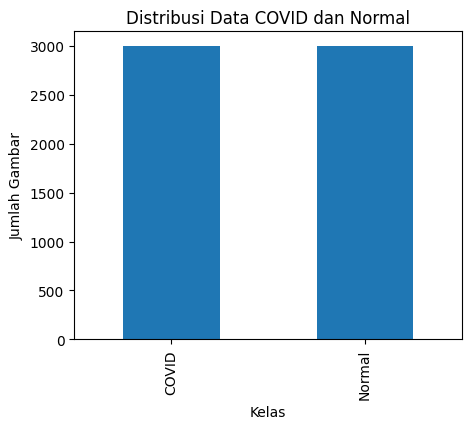

In [ ]:
print(df["class"].value_counts())

plt.figure(figsize=(5, 4))
df["class"].value_counts().plot(kind="bar")
plt.title("Distribusi Data COVID dan Normal")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.show()

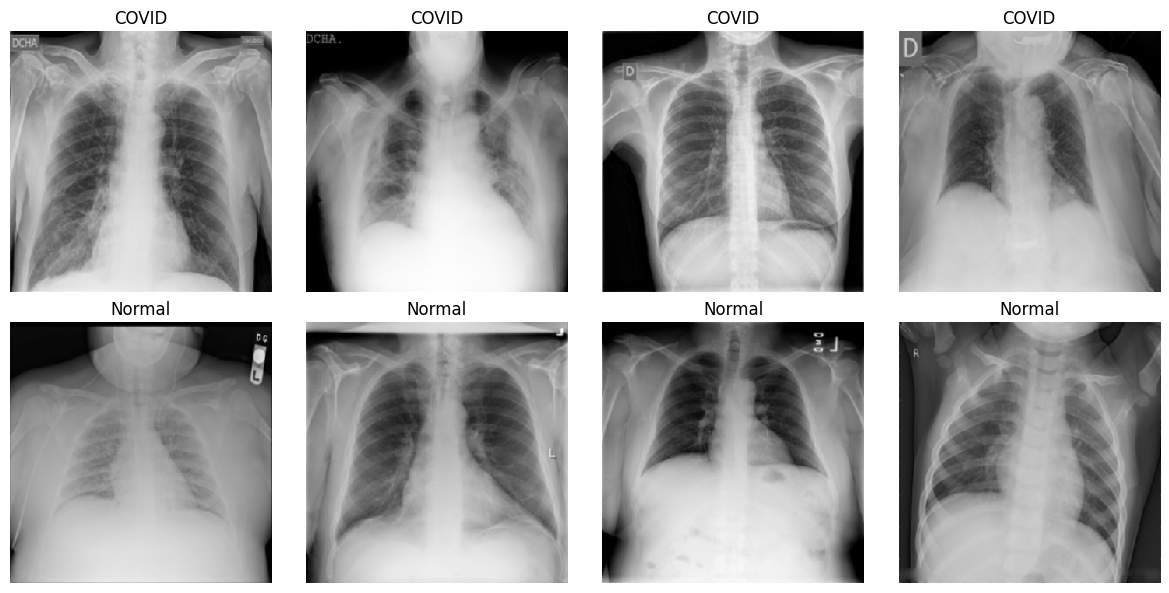

In [ ]:
def show_sample_images(dataframe, n=4):
    sample_df = dataframe.groupby("class").sample(n=n, random_state=SEED)
    plt.figure(figsize=(12, 6))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = tf.keras.utils.load_img(row["path"], target_size=(224, 224))
        plt.subplot(2, n, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(row["class"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_sample_images(df, n=4)

# 2. Desain Arsitektur Hybrid CNN + Transformer



## 2.1 Split Data and Preprocessing


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=SEED
)

print("Train + Validasi:", len(train_val_df))
print("Test       :", len(test_df))

print("\train_val Distribution:")
print(train_val_df["class"].value_counts())

print("\nTest Distribution:")
print(test_df["class"].value_counts())

Train + Validasi: 5100
Test akhir      : 900

Distribusi train_val:
class
Normal    2550
COVID     2550
Name: count, dtype: int64

Distribusi test:
class
COVID     450
Normal    450
Name: count, dtype: int64


In [ ]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)

    label = tf.cast(label, tf.float32)
    return image, label


def create_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=True):
    paths = dataframe["path"].values
    labels = dataframe["label"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=SEED)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

## 2.2  Model CNN + Transformer Function


In [ ]:
def build_cnn_transformer_model(
    img_size=224,
    transformer_dim=128,
    num_heads=4,
    ff_dim=256,
    dropout_rate=0.2,
    learning_rate=1e-4
):
    inputs = keras.Input(shape=(img_size, img_size, 3), name="input_image")

    x = layers.RandomFlip("horizontal", name="random_flip")(inputs)
    x = layers.RandomRotation(0.05, name="random_rotation")(x)
    x = layers.RandomZoom(0.1, name="random_zoom")(x)
    x = preprocess_input(x)

    cnn_base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3)
    )
    cnn_base.trainable = False

    x = cnn_base(x, training=False)
    x = layers.Conv2D(transformer_dim, kernel_size=1, padding="same", name="projection_conv")(x)

    h = x.shape[1]
    w = x.shape[2]
    num_patches = h * w

    x = layers.Reshape((num_patches, transformer_dim), name="reshape_to_tokens")(x)

    positions = tf.range(start=0, limit=num_patches, delta=1)
    position_embedding = layers.Embedding(
        input_dim=num_patches,
        output_dim=transformer_dim,
        name="positional_embedding"
    )(positions)

    x = x + position_embedding

    x1 = layers.LayerNormalization(epsilon=1e-6, name="transformer_norm_1")(x)

    attention_output, attention_scores = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=transformer_dim // num_heads,
        dropout=dropout_rate,
        name="multi_head_attention"
    )(x1, x1, return_attention_scores=True)

    x2 = layers.Add(name="attention_residual")([x, attention_output])

    x3 = layers.LayerNormalization(epsilon=1e-6, name="transformer_norm_2")(x2)

    ffn = keras.Sequential([
        layers.Dense(ff_dim, activation="gelu"),
        layers.Dropout(dropout_rate),
        layers.Dense(transformer_dim),
    ], name="feed_forward_network")

    x3 = ffn(x3)
    x = layers.Add(name="ffn_residual")([x2, x3])
    x = layers.LayerNormalization(epsilon=1e-6, name="final_norm")(x)
    x = layers.GlobalAveragePooling1D(name="global_average_pooling")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)
    x = layers.Dense(128, activation="relu", name="dense_128")(x)
    x = layers.Dropout(dropout_rate, name="dropout_2")(x)

    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = Model(inputs=inputs, outputs=outputs, name="CNN_Transformer_COVID_Classifier")

    attention_model = Model(
        inputs=inputs,
        outputs=attention_scores,
        name="Attention_Map_Model"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model, attention_model

In [ ]:
model, attention_model = build_cnn_transformer_model(img_size=IMG_SIZE)
model.summary()

Model: "CNN_Transformer_COVID_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ random_zoom[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection_conv     │ (None, 7, 7, 128) │    163,968 │ efficientnetb0[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_to_tokens   │ (None, 49, 128)   │          0 │ projection_conv[… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 49, 128)   │          0 │ reshape_to_token… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_norm_1  │ (None, 49, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ [(None, 49, 128), │     66,048 │ transformer_norm… │
│ (MultiHeadAttentio… │ (None, 4, 49,     │            │ transformer_norm… │
│                     │ 49)]              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_residual  │ (None, 49, 128)   │          0 │ add[0][0],        │
│ (Add)               │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_norm_2  │ (None, 49, 128)   │        256 │ attention_residu… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feed_forward_netwo… │ (None, 49, 128)   │     65,920 │ transformer_norm… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_residual (Add)  │ (None, 49, 128)   │          0 │ attention_residu… │
│                     │                   │            │ feed_forward_net… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_norm          │ (None, 49, 128)   │        256 │ ffn_residual[0][… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ final_norm[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ global_average_p

 Total params: 4,362,916 (16.64 MB)

 Trainable params: 313,345 (1.20 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

# 3. Training & Hyperparameter Tuning





In [ ]:
param_grid = [
    {
        "transformer_dim": 128,
        "num_heads": 4,
        "ff_dim": 256,
        "dropout_rate": 0.2,
        "learning_rate": 1e-4
    },
    {
        "transformer_dim": 128,
        "num_heads": 4,
        "ff_dim": 512,
        "dropout_rate": 0.3,
        "learning_rate": 1e-4
    },
    {
        "transformer_dim": 256,
        "num_heads": 4,
        "ff_dim": 512,
        "dropout_rate": 0.3,
        "learning_rate": 5e-5
    }
]

N_SPLITS = 3
EPOCHS_TUNING = 2

In [ ]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

tuning_results = []

X = train_val_df["path"].values
y = train_val_df["label"].values

for param_id, params in enumerate(param_grid):
    print("=" * 70)
    print(f"Uji Hyperparameter ke-{param_id + 1}")
    print(params)

    fold_aucs = []
    fold_accs = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print("-" * 70)
        print(f"Fold {fold + 1}/{N_SPLITS}")

        fold_train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
        fold_val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

        train_ds = create_dataset(fold_train_df, shuffle=True)
        val_ds = create_dataset(fold_val_df, shuffle=False)

        keras.backend.clear_session()

        model, _ = build_cnn_transformer_model(
            img_size=IMG_SIZE,
            transformer_dim=params["transformer_dim"],
            num_heads=params["num_heads"],
            ff_dim=params["ff_dim"],
            dropout_rate=params["dropout_rate"],
            learning_rate=params["learning_rate"]
        )

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_auc",
                patience=2,
                mode="max",
                restore_best_weights=True
            )
        ]

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS_TUNING,
            callbacks=callbacks,
            verbose=1
        )

        val_loss, val_acc, val_auc = model.evaluate(val_ds, verbose=0)

        print(f"Fold {fold + 1} - Val Accuracy: {val_acc:.4f}, Val AUC: {val_auc:.4f}")

        fold_accs.append(val_acc)
        fold_aucs.append(val_auc)

    mean_acc = np.mean(fold_accs)
    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    tuning_results.append({
        "param_id": param_id + 1,
        "params": params,
        "mean_accuracy": mean_acc,
        "mean_auc": mean_auc,
        "std_auc": std_auc
    })

    print("\n Hyperparamater Result", param_id + 1)
    print("Mean Accuracy:", mean_acc)
    print("Mean AUC     :", mean_auc)
    print("Std AUC      :", std_auc)

Uji Hyperparameter ke-1
{'transformer_dim': 128, 'num_heads': 4, 'ff_dim': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0001}
----------------------------------------------------------------------
Fold 1/3
Epoch 1/2
213/213 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.8150 - auc: 0.8907 - loss: 0.4164 - val_accuracy: 0.8700 - val_auc: 0.9498 - val_loss: 0.2986
Epoch 2/2
213/213 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.8862 - auc: 0.9488 - loss: 0.2803 - val_accuracy: 0.7788 - val_auc: 0.9574 - val_loss: 0.5126
Fold 1 - Val Accuracy: 0.7788, Val AUC: 0.9574
----------------------------------------------------------------------
Fold 2/3
Epoch 1/2
213/213 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - accuracy: 0.8021 - auc: 0.8872 - loss: 0.4246 - val_accuracy: 0.8394 - val_auc: 0.9391 - val_loss: 0.3511
Epoch 2/2
213/213 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.8688 - auc: 0.9403 - loss: 0.3075 - val_accuracy: 0.8759 - val_auc: 0.9569 - val_loss: 0.2909
Fold 2 - Val Accuracy:

In [ ]:
results_df = pd.DataFrame(tuning_results)
results_df

,param_id,params,mean_accuracy,mean_auc,std_auc
0,1,"{'transformer_dim': 128, 'num_heads': 4, 'ff_d...",0.842549,0.957431,0.000460
1,2,"{'transformer_dim': 128, 'num_heads': 4, 'ff_d...",0.859608,0.952428,0.002832
2,3,"{'transformer_dim': 256, 'num_heads': 4, 'ff_d...",0.844902,0.953388,0.001328


In [ ]:
best_result = max(tuning_results, key=lambda x: x["mean_auc"])
best_params = best_result["params"]

print("Hyperparameter terbaik:")
print(best_params)
print("Mean AUC terbaik:", best_result["mean_auc"])

Hyperparameter terbaik:
{'transformer_dim': 128, 'num_heads': 4, 'ff_dim': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0001}
Mean AUC terbaik: 0.9574311176935831


# 4. Validation



In [ ]:
final_train_df, final_val_df = train_test_split(
    train_val_df,
    test_size=0.15,
    stratify=train_val_df["label"],
    random_state=SEED
)

print("Final Train:", len(final_train_df))
print("Final Val  :", len(final_val_df))
print("Final Test :", len(test_df))

train_ds = create_dataset(final_train_df, shuffle=True)
val_ds = create_dataset(final_val_df, shuffle=False)
test_ds = create_dataset(test_df, shuffle=False)

Final Train: 4335
Final Val  : 765
Final Test : 900


In [ ]:
keras.backend.clear_session()

EPOCHS_FINAL = 20
steps_per_epoch = len(final_train_df) // BATCH_SIZE

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=best_params["learning_rate"],
    decay_steps=EPOCHS_FINAL * steps_per_epoch,
    alpha=0.1
)

final_model, final_attention_model = build_cnn_transformer_model(
    img_size=IMG_SIZE,
    transformer_dim=best_params["transformer_dim"],
    num_heads=best_params["num_heads"],
    ff_dim=best_params["ff_dim"],
    dropout_rate=best_params["dropout_rate"],
    learning_rate=lr_schedule
)
final_model.summary()

Model: "CNN_Transformer_COVID_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ random_zoom[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection_conv     │ (None, 7, 7, 128) │    163,968 │ efficientnetb0[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_to_tokens   │ (None, 49, 128)   │          0 │ projection_conv[… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 49, 128)   │          0 │ reshape_to_token… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_norm_1  │ (None, 49, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ [(None, 49, 128), │     66,048 │ transformer_norm… │
│ (MultiHeadAttentio… │ (None, 4, 49,     │            │ transformer_norm… │
│                     │ 49)]              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_residual  │ (None, 49, 128)   │          0 │ add[0][0],        │
│ (Add)               │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_norm_2  │ (None, 49, 128)   │        256 │ attention_residu… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feed_forward_netwo… │ (None, 49, 128)   │     65,920 │ transformer_norm… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_residual (Add)  │ (None, 49, 128)   │          0 │ attention_residu… │
│                     │                   │            │ feed_forward_net… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_norm          │ (None, 49, 128)   │        256 │ ffn_residual[0][… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ final_norm[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ global_average_p

 Total params: 4,362,916 (16.64 MB)

 Trainable params: 313,345 (1.20 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=4,
        mode="max",
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        "/content/best_cnn_transformer_model.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True
    )
]

history = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINAL,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 38s 83ms/step - accuracy: 0.8115 - auc: 0.8938 - loss: 0.4112 - val_accuracy: 0.8379 - val_auc: 0.9433 - val_loss: 0.3725
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.8830 - auc: 0.9477 - loss: 0.2880 - val_accuracy: 0.8654 - val_auc: 0.9617 - val_loss: 0.3257
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.9027 - auc: 0.9640 - loss: 0.2392 - val_accuracy: 0.8013 - val_auc: 0.9661 - val_loss: 0.4767
Epoch 4/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.9077 - auc: 0.9682 - loss: 0.2245 - val_accuracy: 0.8824 - val_auc: 0.9723 - val_loss: 0.2819
Epoch 5/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.9087 - auc: 0.9701 - loss: 0.2180 - val_accuracy: 0.8915 - val_auc: 0.9748 - val_loss: 0.2694
Epoch 6/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.9216 - auc: 0.9754 - loss: 0.1984 - val_accuracy: 0.9216 - val_auc: 0.9793 - val_loss: 0.2017
Epoch 7/20
271/271 ━━━━━━━━━

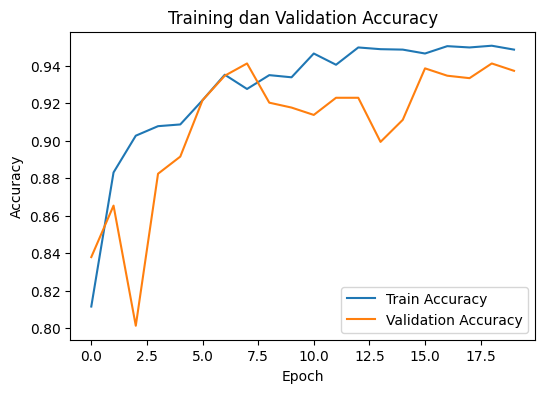

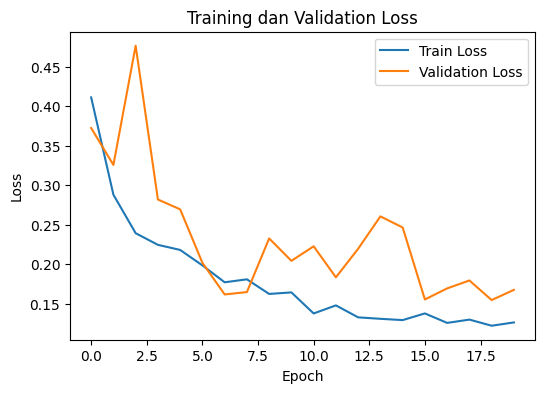

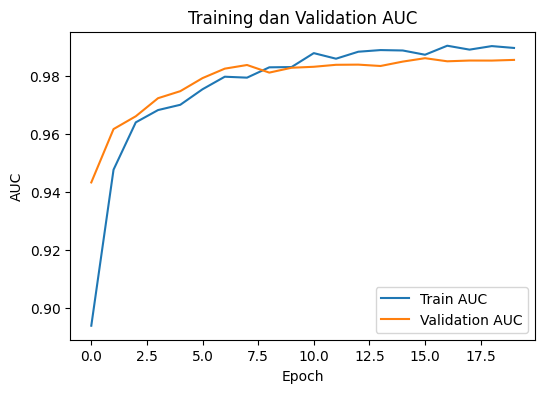

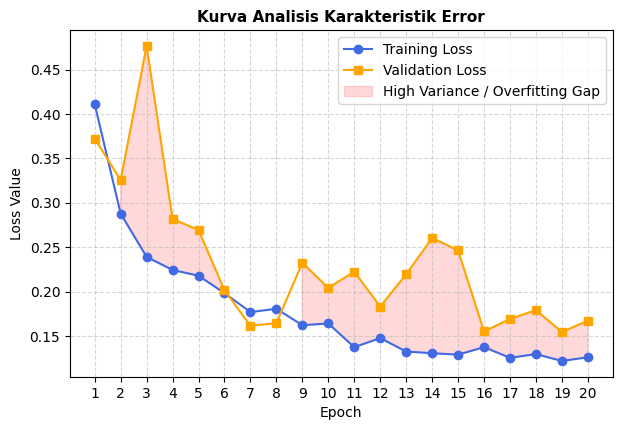

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training dan Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training dan Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Validation AUC")
plt.title("Training dan Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()

epochs_range = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(7, 4.5))
loss_gap = np.array(history.history["val_loss"]) - np.array(history.history["loss"])

plt.plot(epochs_range, history.history["loss"], label="Training Loss", color="royalblue", marker="o")
plt.plot(epochs_range, history.history["val_loss"], label="Validation Loss", color="orange", marker="s")
plt.fill_between(epochs_range, history.history["loss"], history.history["val_loss"],
                 where=(np.array(history.history["val_loss"]) >= np.array(history.history["loss"])),
                 color="red", alpha=0.15, label="High Variance / Overfitting Gap")

plt.title("Kurva Analisis Karakteristik Error", fontsize=11, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.xticks(epochs_range)
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 4.1 Evaluasi pada Test Set

In [ ]:
test_loss, test_acc, test_auc = final_model.evaluate(test_ds, verbose=1)

print("Test Loss    :", test_loss)
print("Test Accuracy:", test_acc)
print("Test AUC     :", test_auc)

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9244 - auc: 0.9854 - loss: 0.1792
Test Loss    : 0.17920000851154327
Test Accuracy: 0.9244444370269775
Test AUC     : 0.9853653907775879


In [ ]:
y_true = test_df["label"].values
y_prob = final_model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Normal", "COVID"]))

57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step
Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.89      0.92       450
       COVID       0.90      0.96      0.93       450

    accuracy                           0.92       900
   macro avg       0.93      0.92      0.92       900
weighted avg       0.93      0.92      0.92       900



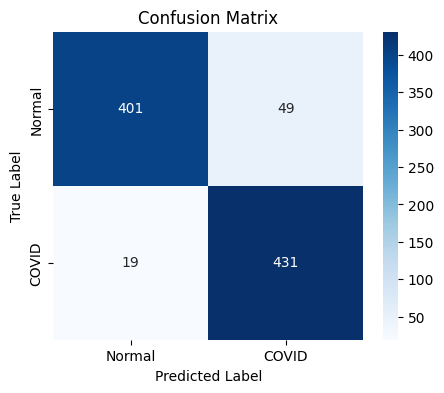

Final Test Accuracy: 0.9244444444444444
Final Test AUC     : 0.9854469135802468


In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "COVID"],
    yticklabels=["Normal", "COVID"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

auc_score = roc_auc_score(y_true, y_prob)
acc_score = accuracy_score(y_true, y_pred)

print("Final Test Accuracy:", acc_score)
print("Final Test AUC     :", auc_score)

# 5. Interpretasi / XAI



In [ ]:
def get_single_image(path):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    return image

In [ ]:
sample_row = test_df.sample(1, random_state=SEED).iloc[0]
sample_path = sample_row["path"]
sample_label = sample_row["class"]

sample_img = get_single_image(sample_path)
sample_batch = tf.expand_dims(sample_img, axis=0)

pred_prob = final_model.predict(sample_batch)[0][0]
pred_class = "COVID" if pred_prob >= 0.5 else "Normal"

print("Real Label           :", sample_label)
print("Model Prediction     :", pred_class)
print("COVID Probability    :", pred_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Label asli         : COVID
Prediksi model     : Normal
Probabilitas COVID : 0.3466994


In [ ]:
attention_scores = final_attention_model.predict(sample_batch)
print("Shape attention scores:", attention_scores.shape)

attn = attention_scores[0]
attn_mean = np.mean(attn, axis=0)
token_attention = np.mean(attn_mean, axis=0)

grid_size = int(np.sqrt(token_attention.shape[0]))
attention_map = token_attention.reshape(grid_size, grid_size)

attention_map_resized = tf.image.resize(
    attention_map[..., np.newaxis],
    [IMG_SIZE, IMG_SIZE]
).numpy().squeeze()

attention_map_resized = (attention_map_resized - attention_map_resized.min()) / (
    attention_map_resized.max() - attention_map_resized.min() + 1e-8
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Shape attention scores: (1, 4, 49, 49)


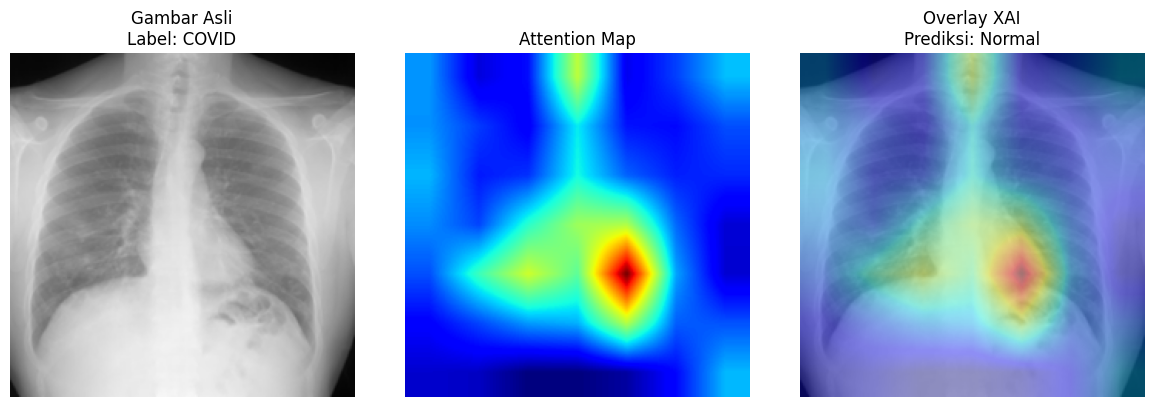

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_img.numpy().astype("uint8"))
plt.title(f"Real Picture\nLabel: {sample_label}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(attention_map_resized, cmap="jet")
plt.title("Attention Map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sample_img.numpy().astype("uint8"))
plt.imshow(attention_map_resized, cmap="jet", alpha=0.4)
plt.title(f"Overlay XAI\nPrediction: {pred_class}")
plt.axis("off")

plt.tight_layout()
plt.show()

## 5.1 Interpretasi Tambahan dengan SHAP



=== Memulai Proses Inisialisasi SHAP ===
Background shape: (5, 224, 224, 3)
Explain images shape: (3, 224, 224, 3)
Rentang nilai piksel asli: 0.0 sampai 251.216552734375


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_image
Received: inputs=['Tensor(shape=(3, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_image
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


SHAP values shape untuk plotting: (3, 224, 224, 3)
-> Mendeteksi rentang piksel 0-255. Melakukan scaling ke rentang 0.0 - 1.0 untuk visualisasi...

=== Menampilkan SHAP Image Plot ===


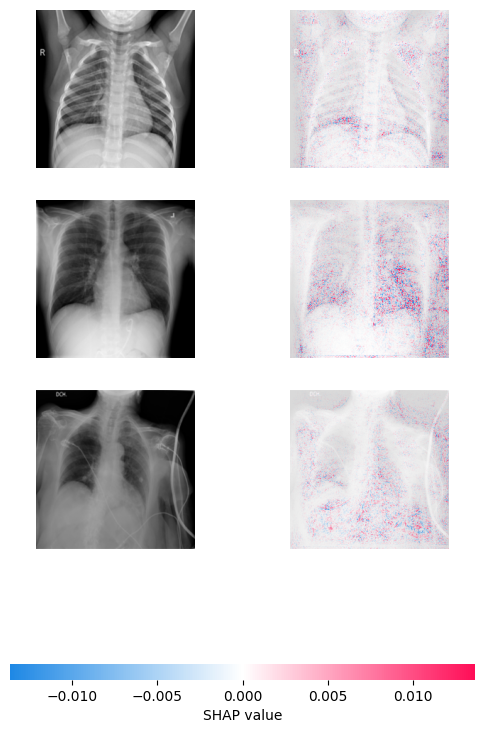

In [ ]:
import shap
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

try:
    print("=== Memulai Proses Inisialisasi SHAP ===")

    test_images = None
    test_labels = None
    for images, labels in test_ds.take(1):
        test_images = images.numpy()
        test_labels = labels.numpy()
        break

    background = test_images[:5].astype(np.float32)
    explain_images = test_images[5:8].astype(np.float32)

    print(f"Background shape: {background.shape}")
    print(f"Explain images shape: {explain_images.shape}")

    max_pixel = explain_images.max()
    min_pixel = explain_images.min()
    print(f"Rentang nilai piksel asli: {min_pixel} sampai {max_pixel}")

    explainer = shap.GradientExplainer(final_model, background)

    shap_values = explainer.shap_values(explain_images)

    if isinstance(shap_values, list):
        print(f"SHAP mengembalikan list dengan {len(shap_values)} elemen kelas.")
        shap_values_to_plot = shap_values[0]
    else:
        if len(shap_values.shape) == 5:
            shap_values_to_plot = shap_values[..., 0]
        else:
            shap_values_to_plot = shap_values

    print(f"SHAP values shape untuk plotting: {shap_values_to_plot.shape}")

    if max_pixel > 1.0:
        print("-> Mendeteksi rentang piksel 0-255. Melakukan scaling ke rentang 0.0 - 1.0 untuk visualisasi...")
        explain_images_scaled = explain_images / 255.0
    else:
        print("-> Mendeteksi rentang piksel sudah aman (0.0 - 1.0).")
        explain_images_scaled = explain_images

    print("\n=== Menampilkan SHAP Image Plot ===")
    shap.image_plot(shap_values_to_plot, explain_images_scaled)

except Exception as e:
    print("\n[PERINGATAN] SHAP tidak berhasil dijalankan.")
    print("Tidak masalah, gunakan Attention Map sebagai XAI utama.")
    print("Detail Error:", e)
    import traceback
    traceback.print_exc()

In [ ]:
final_model.save("/content/final_cnn_transformer_covid_model.keras")
print("Model berhasil disimpan di /content/final_cnn_transformer_covid_model.keras")

Model berhasil disimpan di /content/final_cnn_transformer_covid_model.keras
